# Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning

### 1. Importing Necessary Libraries 

In [63]:
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns            # For statistical data visualization
import joblib                    # For saving and loading models
import math                      # For mathematical operations

from sklearn.datasets import fetch_california_housing                           # For loading the California housing dataset
from sklearn.model_selection import train_test_split                            # For splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler                                # For feature scaling
from sklearn.linear_model import LinearRegression, Ridge                        # For linear regression and ridge regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor   # For ensemble regression models
from sklearn.svm import SVR                                                     # For support vector regression
from sklearn.tree import DecisionTreeRegressor                                  # For decision tree regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # For model evaluation metrics
from sklearn.model_selection import GridSearchCV, cross_val_score               # For hyperparameter tuning and cross-validation

import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

### 2. Loading Dataset 

In [64]:
data = fetch_california_housing(as_frame=True)                          # Load the California housing dataset as a DataFrame
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)  # Combine features and target into a single DataFrame
display(df.head())                                                      # Display the first few rows of the DataFrame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 3. Exploratory Data Analysis

In [65]:
# Display the shape of the dataset
print("Dataset shape:", df.shape)  # Print the shape of the dataset

Dataset shape: (20640, 9)


In [66]:
# Display information about the dataset
print("Dataset information:")
df.info()                          # Display information about the dataset, including data types and non-null counts

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [67]:
# Display summary statistics of the dataset
print("Summary statistics of the dataset:") 
display(df.describe())             # Display summary statistics of the dataset

Summary statistics of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [68]:
# Check for missing values in the dataset
print("Missing values in the dataset:")
display(df.isnull().sum())           # Display the count of missing values in each column

Missing values in the dataset:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

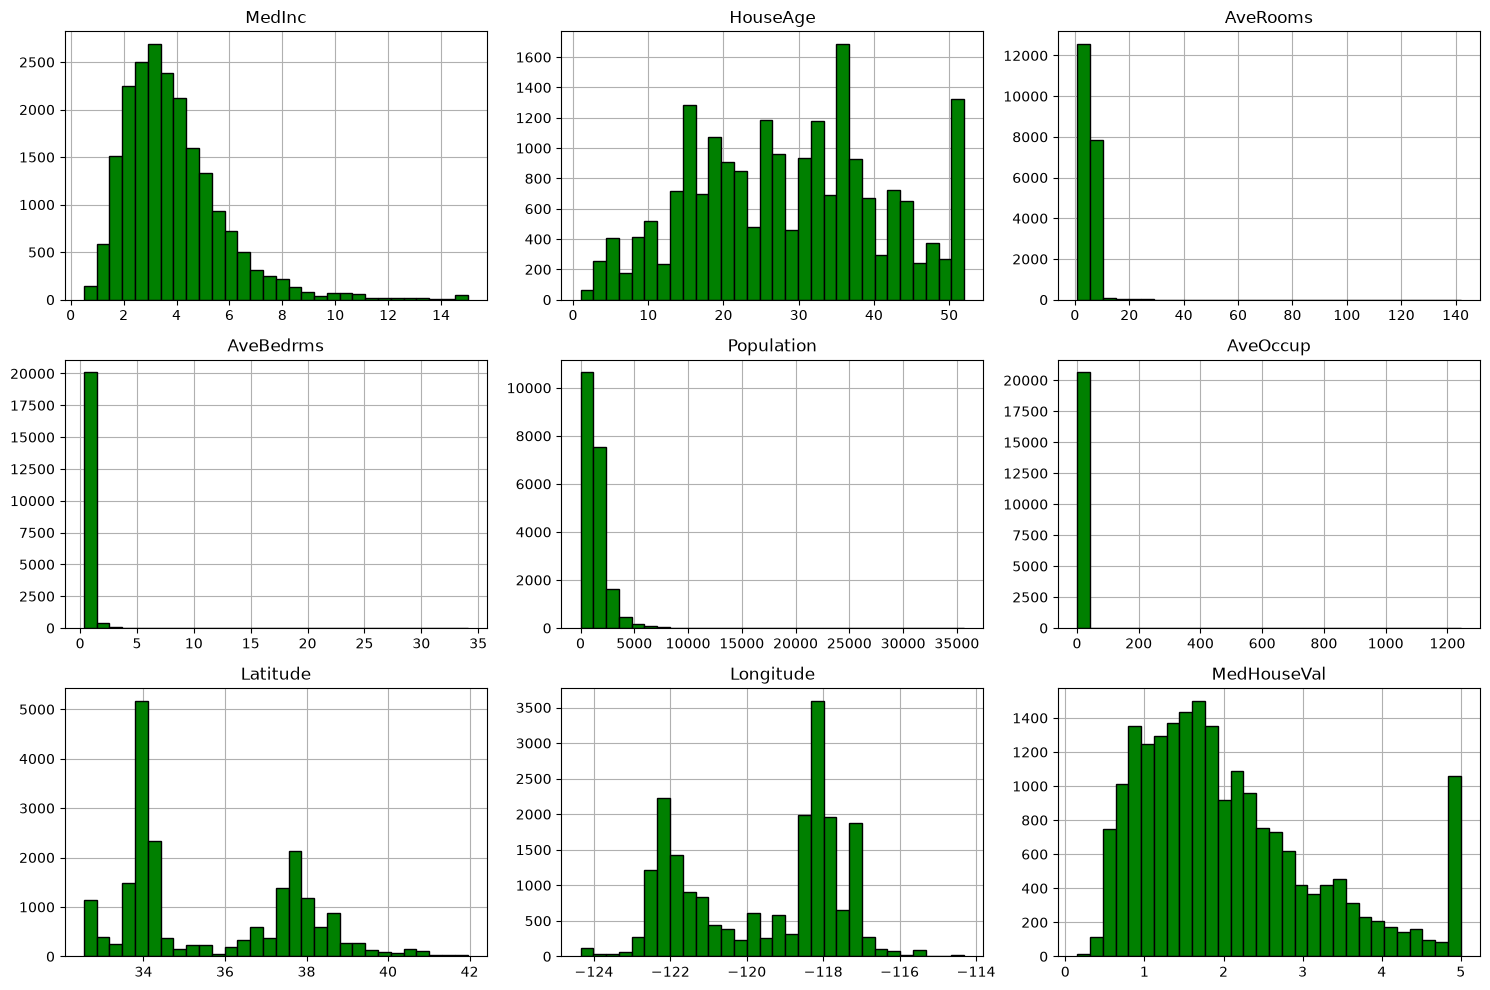

In [69]:
# Visualize the distribution of each feature in the dataset using histograms
axes = df.hist(
    bins=30,              # Number of bins for the histogram
    figsize=(15, 10),     # Size of the figure
    edgecolor='black',    # Color of the edges of the bars
    zorder=2,             # Z-order for layering the histogram bars
    color='green'         # Color of the bars
)

for ax in axes.flatten():
    ax.grid(True, zorder=0)      # Grid behind bars

plt.tight_layout()
plt.show()                        

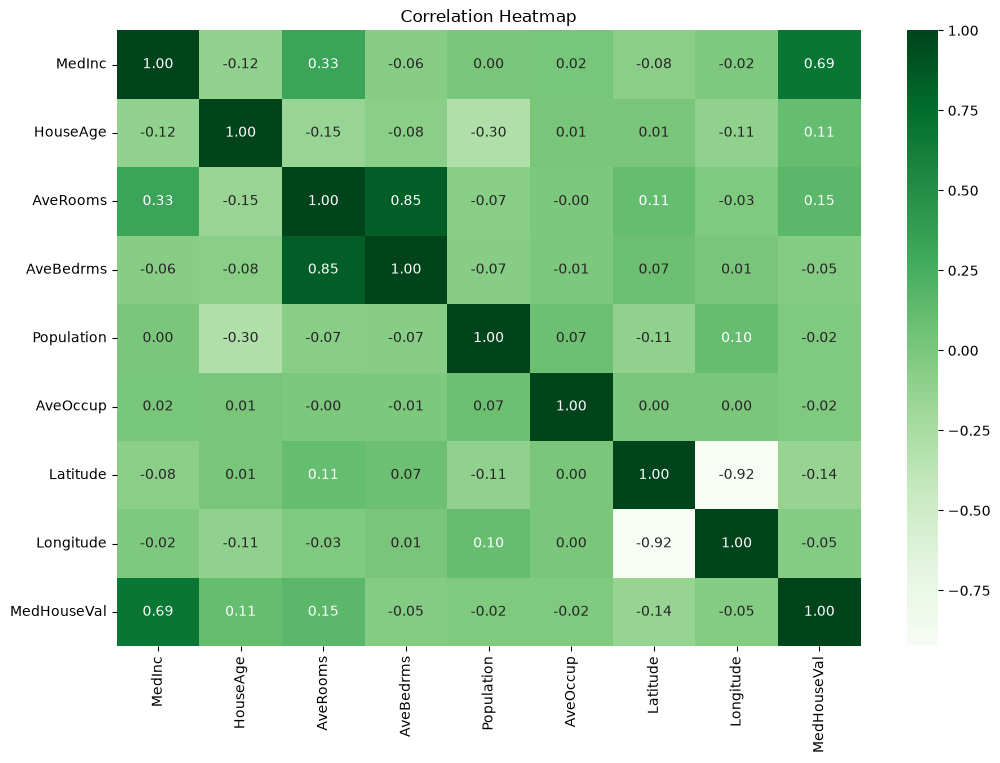

In [70]:
# Visualize the correlation matrix of the dataset using a heatmap
plt.figure(figsize=(12, 8))                              # Set the figure size for the heatmap
corr = df.corr()                                         # Calculate the correlation matrix of the dataset
sns.heatmap(corr, annot=True, cmap='Greens', fmt=".2f")  # Create a heatmap of the correlation matrix
plt.title("Correlation Heatmap")
plt.show()

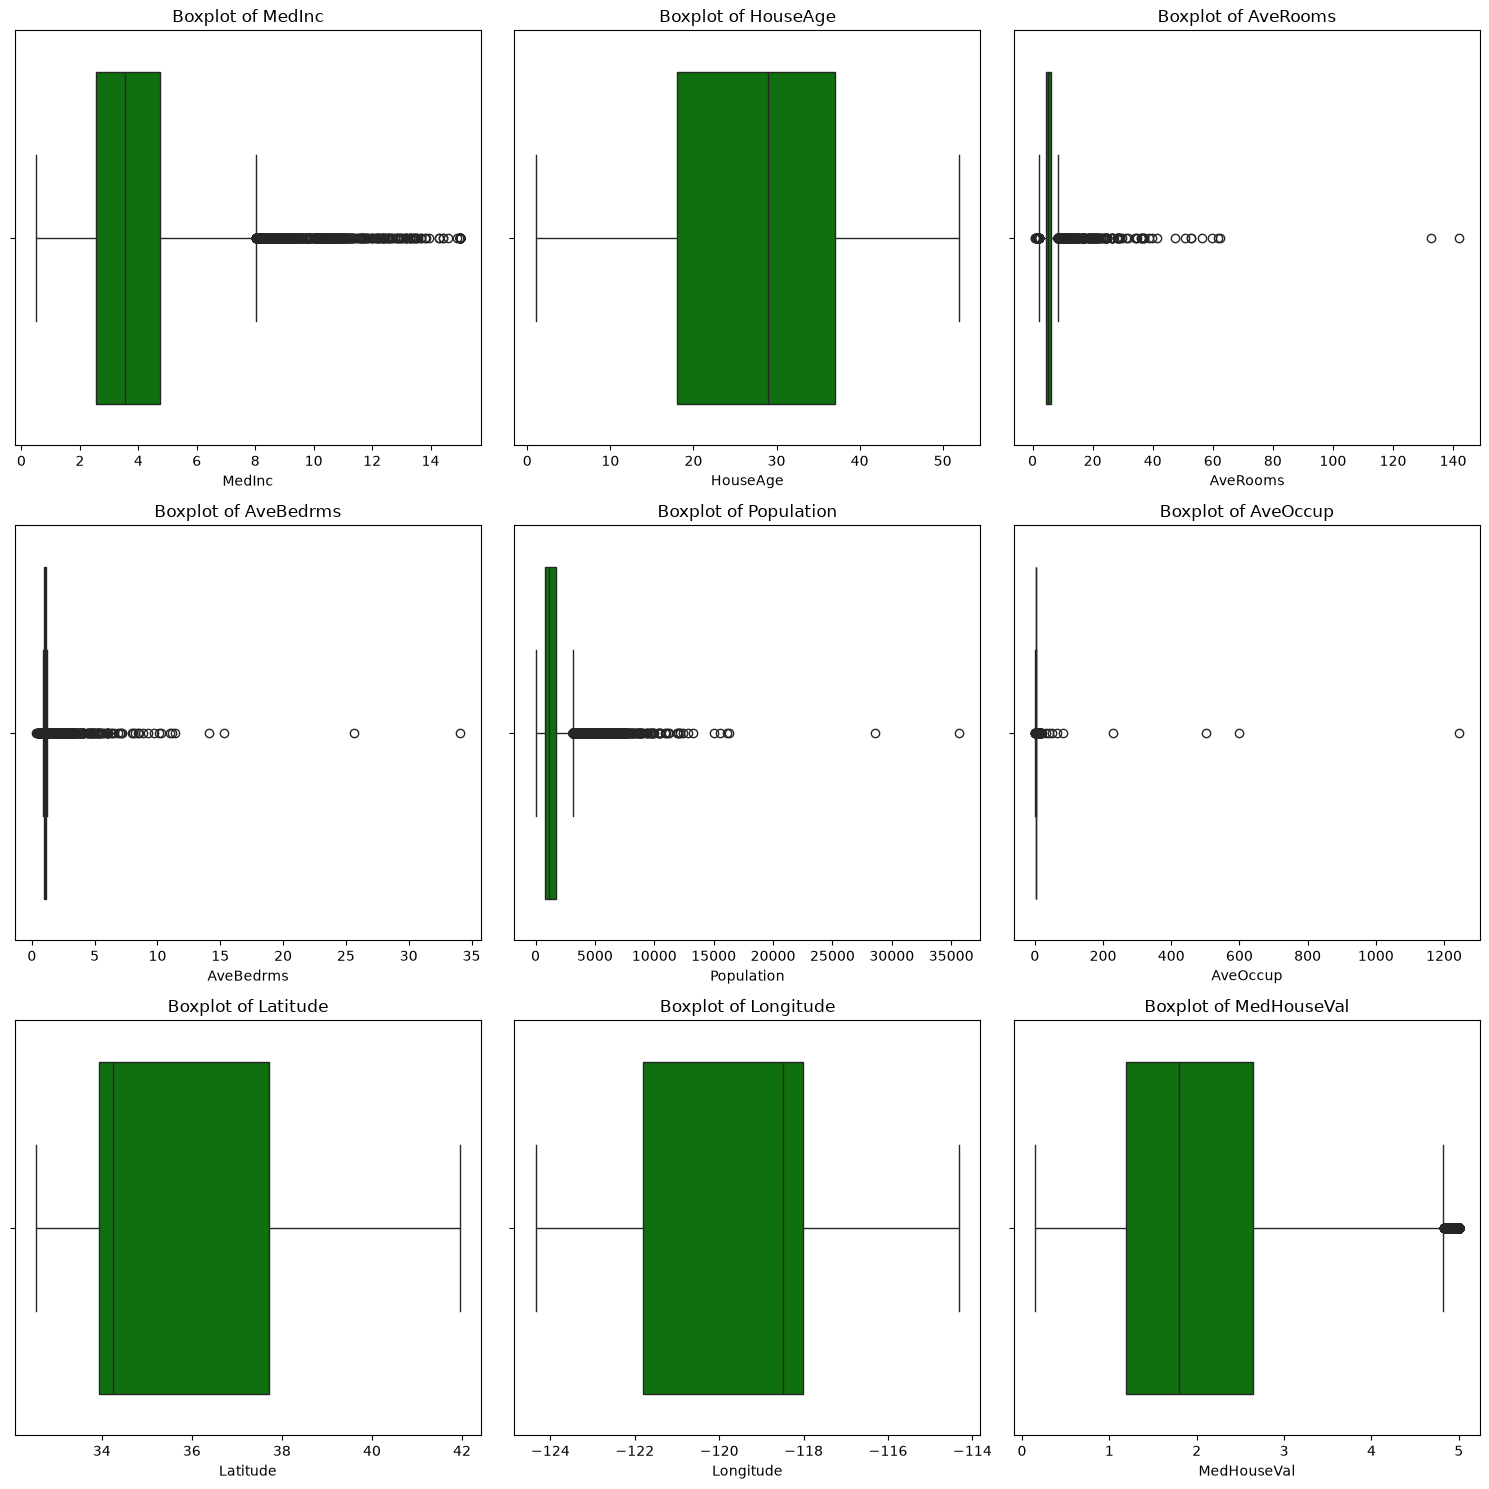

In [71]:
# Detect the outliers in the dataset using boxplots for each feature
n_cols = len(df.columns)
cols = 3
rows = math.ceil(n_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], color='green', ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

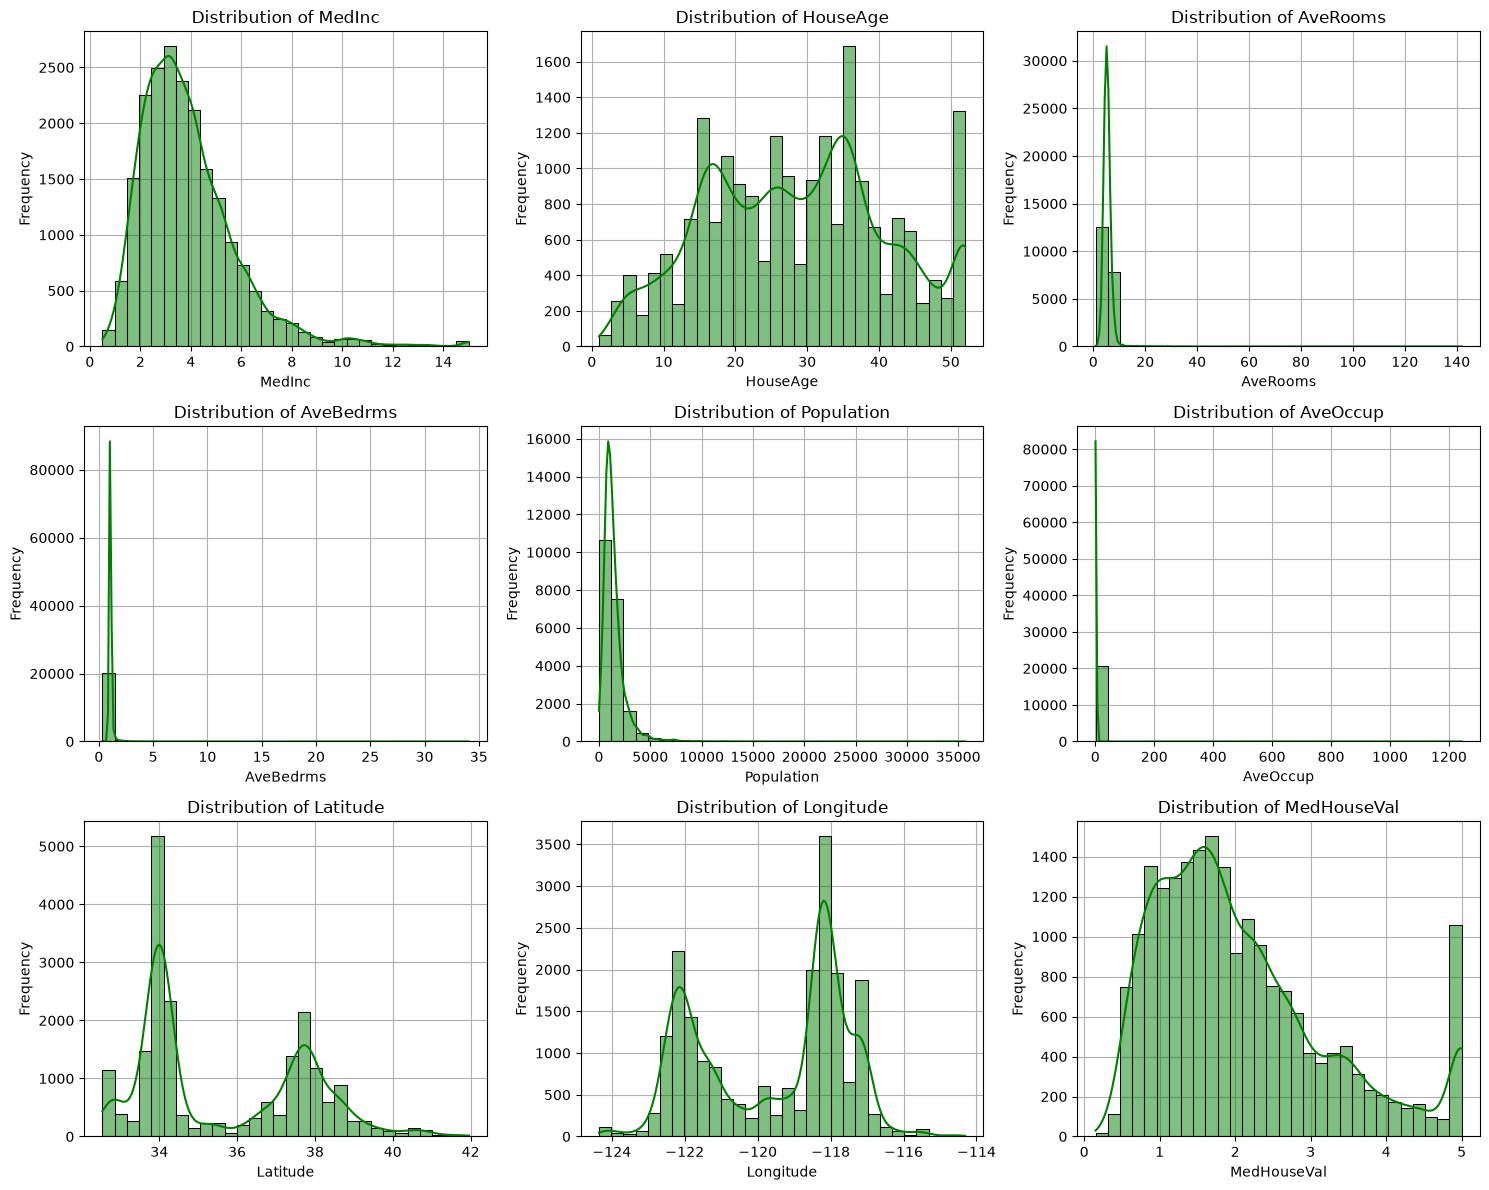

In [72]:
# Visualize the distribution of each feature in the dataset using histograms with KDE overlay
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, column in zip(axes, df.columns):
    sns.histplot(
        df[column],                     # data for this feature
        bins=30,                        # number of histogram bins
        kde=True,                       # overlay a KDE for smoother distribution view
        color='green',
        ax=ax                           # plot into the current subplot axis
    )
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 4. Pre-Processing

In [73]:
# Train/Test split of the dataset
X = df.drop("MedHouseVal", axis=1)  # Features (all columns except the target)
y = df["MedHouseVal"]               # Target variable (Median House Value)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
    )  # Split the dataset into training and testing sets

In [74]:
# Feature scaling using StandardScaler
scaler = StandardScaler()                      # Create an instance of StandardScaler for feature scaling
scaler.fit(X_train)                            # Fit the scaler on the training data  
X_train_scaled = scaler.transform(X_train)     # Transform the training data
X_test_scaled = scaler.transform(X_test)       # Transform the testing data

### 5. Model Training

In [75]:
# Define a dictionary of regression models to be trained and evaluated
models = {
    "Linear Regression": LinearRegression(),  # Linear Regression model
    "Ridge Regression": Ridge(alpha=1.0),      # Ridge Regression model with alpha=1.0
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        random_state=42
        ),  # Random Forest Regressor with 100 trees
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42
        ),  # Gradient Boosting Regressor with 100 trees and learning rate of 0.1
    "Support Vector Regression": SVR(
        kernel='rbf', 
        C=100, 
        gamma=0.1, 
        epsilon=.1
        ),  # Support Vector Regression model with RBF kernel, C=100, gamma=0.1, and epsilon=0
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
        )   # Decision Tree Regressor
}

In [76]:
# Train each model and store the trained models in a dictionary
trained_models = {}                      # Dictionary to store trained models
for name, model in models.items():
    print(f"Training {name}...")         # Print the name of the model being trained
    model.fit(X_train_scaled, y_train)   # Fit the model on the scaled training data
    trained_models[name] = model         # Store the trained model in the dictionary

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...
Training Support Vector Regression...
Training Decision Tree...


### 6. Evaluation

In [77]:
# Evaluate each trained model on the test set and store the results
results = {}  # Dictionary to store evaluation results for each model
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)       # Predict the target variable for the test set
    mae = f"{mean_absolute_error(y_test, y_pred):.4f}"   # Calculate Mean Absolute Error
    mse = f"{mean_squared_error(y_test, y_pred):.4f}"    # Calculate Mean Squared Error
    rmse = f"{np.sqrt(mean_squared_error(y_test, y_pred)):.4f}"  # Calculate Root Mean Squared Error
    r2 = f"{r2_score(y_test, y_pred):.4f}"               # Calculate R-squared score

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }  # Store the evaluation metrics in the results dictionary

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)  # Convert the results dictionary to a DataFrame and sort by R2 Score
print("Model Evaluation Results:")
display(results_df)

Model Evaluation Results:


,MAE,MSE,RMSE,R2 Score
Random Forest,0.3278,0.2559,0.5059,0.8047
Gradient Boosting,0.3717,0.2940,0.5422,0.7756
Support Vector Regression,0.3738,0.3245,0.5697,0.7524
Decision Tree,0.4532,0.4930,0.7021,0.6238
Linear Regression,0.5332,0.5559,0.7456,0.5758
Ridge Regression,0.5332,0.5559,0.7456,0.5758


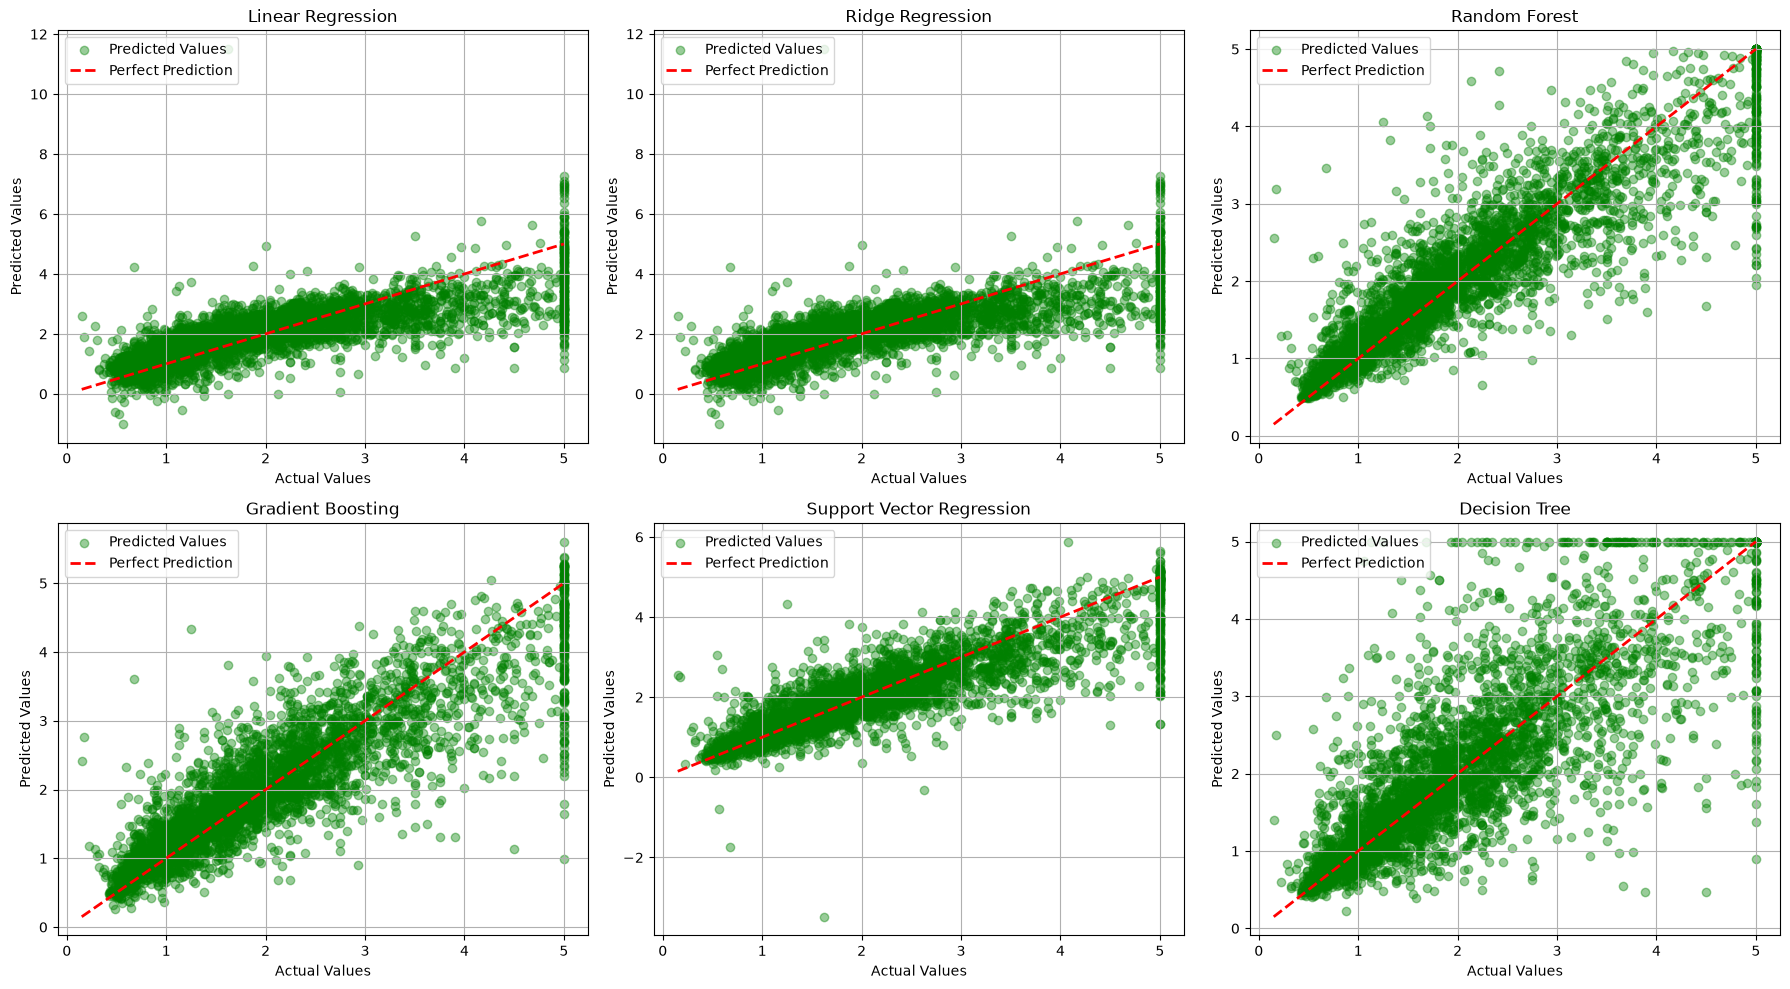

In [ ]:
# Visualize the actual vs predicted values using a scatter plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, m) in zip(axes, trained_models.items()):
    preds = m.predict(X_test_scaled)
    ax.scatter(y_test, preds, alpha=0.4, color='green', label="Predicted Values")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label="Perfect Prediction")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(name)
    ax.legend(loc="upper left")
    ax.grid(True)
plt.tight_layout()
plt.show()

In [79]:
# Check for overfitting by comparing training and testing RMSE for each model
overfit_check = {}
for name, model in trained_models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    overfit_check[name] = {
        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4),
        "Gap (Test - Train)": round(test_rmse - train_rmse, 4)
    }

overfit_df = pd.DataFrame(overfit_check).T.sort_values(by="Gap (Test - Train)", ascending=False)
print("Overfitting Check (large gap = overfitting):")
display(overfit_df)

Overfitting Check (large gap = overfitting):


,Train RMSE,Test RMSE,Gap (Test - Train)
Decision Tree,0.0000,0.7021,0.7021
Random Forest,0.1882,0.5059,0.3177
Support Vector Regression,0.5238,0.5697,0.0459
Gradient Boosting,0.5107,0.5422,0.0315
Ridge Regression,0.7197,0.7456,0.0259
Linear Regression,0.7197,0.7456,0.0259


### 7. Cross-Validation

In [80]:
# Perform cross-validation for each model and store the results
X_scaled_full = scaler.fit_transform(X)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_scaled_full, y,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    cv_results[name] = round(-scores.mean(), 4)

cv_df = pd.DataFrame.from_dict(cv_results, orient="index", columns=["CV RMSE (5-fold)"])
cv_df = cv_df.sort_values(by="CV RMSE (5-fold)")
print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,CV RMSE (5-fold)
Support Vector Regression,0.6415
Gradient Boosting,0.6416
Random Forest,0.6514
Ridge Regression,0.7459
Linear Regression,0.7459
Decision Tree,0.8962


### 8. Hyperparameter Tuning Using GridSearchCV

In [81]:
# Hyperparameter tuning for Decision Tree Regressor using GridSearchCV
dt_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
dt_grid.fit(X_train_scaled, y_train)
print("Best Decision Tree params:", dt_grid.best_params_)

Best Decision Tree params: {'max_depth': 10, 'min_samples_split': 10}


In [82]:
# Hyperparameter tuning for Random Forest Regressor using GridSearchCV
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print("Best Random Forest params:", rf_grid.best_params_)

Best Random Forest params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [83]:
# Hyperparameter tuning for Ridge Regression using GridSearchCV
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
ridge_grid.fit(X_train_scaled, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_)

Best Ridge alpha: {'alpha': 0.01}


### 9. Evaluation of Tuned Models

In [84]:
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_ridge = ridge_grid.best_estimator_


tuned_results = {}
for name, model in [
    ("Tuned Decision Tree", best_dt),
    ("Tuned Random Forest", best_rf),
    ("Tuned Ridge", best_ridge),
]:
    y_pred = model.predict(X_test_scaled)
    tuned_results[name] = {
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2 Score": round(r2_score(y_test, y_pred), 4)
    }

tuned_df = pd.DataFrame(tuned_results).T
print("Tuned Model Performance:")
display(tuned_df)

Tuned Model Performance:


,RMSE,R2 Score
Tuned Decision Tree,0.6454,0.6822
Tuned Random Forest,0.5045,0.8058
Tuned Ridge,0.7456,0.5758


### 10. Final Model Comparison Table (Baseline vs Tuned) 

In [85]:
# Compare the performance of baseline models and tuned models
model_names = ["Linear Regression", "Ridge Regression", "Decision Tree", "Random Forest"]

untuned_rmse = [
    float(results["Linear Regression"]["RMSE"]),
    float(results["Ridge Regression"]["RMSE"]),
    float(results["Decision Tree"]["RMSE"]),
    float(results["Random Forest"]["RMSE"])
]
tuned_rmse = [
    float(results["Linear Regression"]["RMSE"]),
    tuned_results["Tuned Ridge"]["RMSE"],
    tuned_results["Tuned Decision Tree"]["RMSE"],
    tuned_results["Tuned Random Forest"]["RMSE"]
]
untuned_r2 = [
    float(results["Linear Regression"]["R2 Score"]),
    float(results["Ridge Regression"]["R2 Score"]),
    float(results["Decision Tree"]["R2 Score"]),
    float(results["Random Forest"]["R2 Score"])
]
tuned_r2 = [
    float(results["Linear Regression"]["R2 Score"]),
    tuned_results["Tuned Ridge"]["R2 Score"],
    tuned_results["Tuned Decision Tree"]["R2 Score"],
    tuned_results["Tuned Random Forest"]["R2 Score"]
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Untuned RMSE": untuned_rmse,
    "Tuned RMSE": tuned_rmse,
    "Untuned R2": untuned_r2,
    "Tuned R2": tuned_r2
}).sort_values(by="Tuned R2", ascending=False)

print("Final Model Comparison (Untuned vs Tuned):")
display(comparison_df)

Final Model Comparison (Untuned vs Tuned):


,Model,Untuned RMSE,Tuned RMSE,Untuned R2,Tuned R2
3,Random Forest,0.5059,0.5045,0.8047,0.8058
2,Decision Tree,0.7021,0.6454,0.6238,0.6822
1,Ridge Regression,0.7456,0.7456,0.5758,0.5758
0,Linear Regression,0.7456,0.7456,0.5758,0.5758


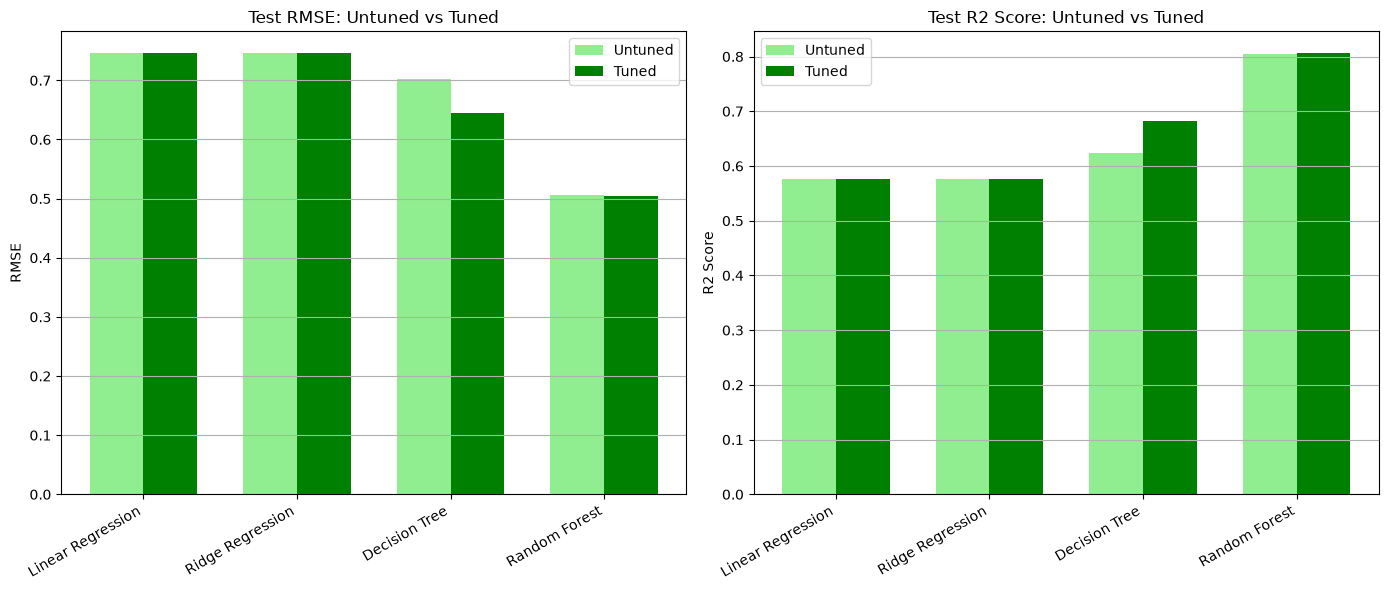

In [87]:
# Visualize the comparison of baseline and tuned models using bar plots for RMSE and R2 Score
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(x - width/2, untuned_rmse, width, label="Untuned", color="lightgreen")
axes[0].bar(x + width/2, tuned_rmse, width, label="Tuned", color="green")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right')
axes[0].set_ylabel("RMSE")
axes[0].set_title("Test RMSE: Untuned vs Tuned")
axes[0].legend()
axes[0].grid(True, axis='y')

axes[1].bar(x - width/2, untuned_r2, width, label="Untuned", color="lightgreen")
axes[1].bar(x + width/2, tuned_r2, width, label="Tuned", color="green")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=30, ha='right')
axes[1].set_ylabel("R2 Score")
axes[1].set_title("Test R2 Score: Untuned vs Tuned")
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=800)  # Save the comparison plot as a PNG file
plt.show()

## Final Model Selection Justification

Building on Task-2, this task focused on model reliability rather than raw accuracy — using cross-validation, overfitting analysis, and GridSearchCV-based hyperparameter tuning across four models: Linear Regression, Ridge Regression, Decision Tree, and Random Forest.

**Overfitting Analysis:** The untuned Decision Tree showed the clearest overfitting signal, with a noticeable gap between train and test RMSE, consistent with its unrestricted depth. Random Forest showed a much smaller gap, since averaging across many trees naturally reduces variance. Linear Regression and Ridge Regression showed no meaningful overfitting — instead they underfit, unable to capture non-linear relationships in the data.

**Effect of Tuning:** Tuning produced a clear improvement for the Decision Tree, with RMSE dropping from 0.7021 (untuned) to 0.6454 (tuned) and R² rising from 0.6238 to 0.6822 — GridSearchCV's constraints on `max_depth` and `min_samples_split` directly reduced overfitting. Random Forest improved only marginally (RMSE 0.5059 → 0.5045, R² 0.8047 → 0.8058), since its ensemble averaging was already controlling variance well even before tuning. Ridge Regression showed no change at all (RMSE and R² identical before and after tuning), confirming that regularization strength was never the limiting factor for this model — its ceiling is architectural, not tunable.

**Why Cross-Validation Is Trusted:** Cross-validation RMSE was used during GridSearchCV instead of relying on a single train-test split, giving a more stable estimate of each model's generalization performance and reducing the risk that results were an artifact of one particular data split.

**Final Model Selected: Tuned Random Forest.** It achieved the lowest test RMSE (0.5045) and highest R² (0.8058) of all models tested, tuned or untuned. It also showed the best-controlled overfitting behavior of any model capable of capturing non-linear relationships in the data.

**Trade-offs:** The Tuned Random Forest is more computationally expensive and less interpretable than Linear or Ridge Regression, and the tuning gain over the untuned Random Forest was small. However, given that this task prioritizes generalization and reliability over simplicity, the marginal accuracy gain combined with strong, consistent performance across metrics justifies selecting it as the final model.